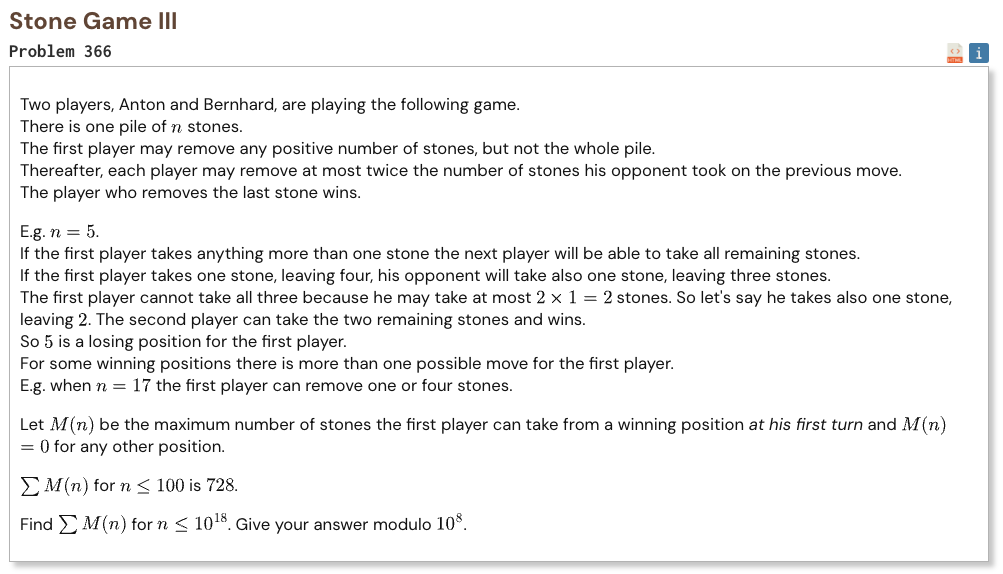

## Initial approach

* this is the Fibonacci Nim game
* losing positions are exactly Fibonacci numbers
* for a winning pile size, the best first move leaves the largest Fibonacci number below it
* so G(n) is the distance from n down to that Fibonacci number
* inside each Fibonacci interval, the values are just 0, 1, 2, ...
* sum each interval with a triangular number
* handle the final partial interval separately

In [1]:
import bisect

MOD = 10 ** 8

def build_tables(limit):
    fib = [1, 2]

    while fib[-1] <= limit:
        fib.append(fib[-1] + fib[-2])

    bsum_at_fib = [0] * len(fib)
    gsum_at_fib = [0] * len(fib)

    bsum_at_fib[0] = 0
    bsum_at_fib[1] = 1

    for i in range(1, len(fib) - 1):
        bsum_at_fib[i + 1] = bsum_at_fib[i] + fib[i] + bsum_at_fib[i - 1]
        gsum_at_fib[i + 1] = gsum_at_fib[i] + bsum_at_fib[i - 1]

    return fib, bsum_at_fib, gsum_at_fib

def solve(limit):
    fib, bsum_at_fib, gsum_at_fib = build_tables(limit)

    def bsum(n):
        if n <= 0:
            return 0

        i = bisect.bisect_right(fib, n) - 1
        return bsum_at_fib[i] + fib[i] + bsum(n - fib[i])

    def gsum(n):
        if n <= 0:
            return 0

        i = bisect.bisect_right(fib, n) - 1
        return gsum_at_fib[i] + bsum(n - fib[i])

    return gsum(limit) % MOD

assert solve(5) == 1
assert solve(17) == 18
assert solve(100) == 252

In [2]:
%%time
result = solve(10 ** 18)
print("Result:", result)

Result: 95653105
CPU times: user 64 μs, sys: 5 μs, total: 69 μs
Wall time: 67 μs
